# **What this notebook does**

reruns Random Forest on different feature sets

compares performance across ablations

identifies the biggest prediction errors

helps interpret what the model is really learning

# **Cell 1 — Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)


In [2]:
# ============================================================
# Notebook 4 export setup
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

EXPORT_DIR = Path("thesis_exports") / "notebook_4"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Export directory:", EXPORT_DIR.resolve())


Export directory: /content/thesis_exports/notebook_4


In [ ]:
# ============================================================
# Export helper functions for thesis tables/figures
# ============================================================

def _format_table_for_export(df_in):
    """Return a copy with readable numeric formatting for PDF tables."""
    out = df_in.copy()
    for col in out.columns:
        if pd.api.types.is_numeric_dtype(out[col]):
            col_lower = str(col).lower()
            if "fips" in col_lower:
                out[col] = out[col].astype(str)
            elif "eal" in col_lower and "log" not in col_lower:
                out[col] = out[col].map(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")
            elif "value" in col_lower and "log" not in col_lower:
                out[col] = out[col].map(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")
            else:
                out[col] = out[col].map(lambda x: f"{x:.4f}" if pd.notnull(x) else "")
    return out

def save_dataframe_table(df_in, filename, title, max_rows=None, fontsize=8, fig_width=None):
    """Save a dataframe as a clean PDF table for thesis exports."""
    data = df_in.copy()
    if max_rows is not None:
        data = data.head(max_rows)

    data = _format_table_for_export(data)

    n_rows, n_cols = data.shape
    if fig_width is None:
        fig_width = max(8, min(17, 1.45 * n_cols))
    fig_height = max(2.2, 0.38 * (n_rows + 2))

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=data.values,
        colLabels=data.columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.25)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("0.75")
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#f2f2f2")

    out_path = EXPORT_DIR / filename
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    plt.close(fig)
    print("Saved table:", out_path)

def save_current_figure(filename_stem):
    """Save the current matplotlib figure as PDF and PNG."""
    pdf_path = EXPORT_DIR / f"{filename_stem}.pdf"
    png_path = EXPORT_DIR / f"{filename_stem}.png"
    plt.savefig(pdf_path, bbox_inches="tight", dpi=300)
    plt.savefig(png_path, bbox_inches="tight", dpi=300)
    print("Saved figure:", pdf_path)
    print("Saved figure:", png_path)


# **Cell 2 — Load cleaned modeling file**

In [ ]:
CSV_PATH = "/content/nri_wildfire_county_model_base.csv"

df = pd.read_csv(CSV_PATH, dtype={"county_fips": str})
df["county_fips"] = df["county_fips"].str.zfill(5)

# Drop duplicate columns if present
drop_cols = [c for c in ["state_pred", "county_pred"] if c in df.columns]
df = df.drop(columns=drop_cols)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Shape: (3144, 15)


,state,county,county_fips,wildfire_eal,log_wildfire_eal,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita
0,Alabama,Autauga,01001,3.626224e+04,10.498560,58764,1.024141e+10,27630646.0,610.470508,38.040712,55.120865,96.260178,1.677625e+07,45261.229851,174280.275458
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,231365,5.160230e+10,155012958.0,2047.738775,44.243003,93.002545,112.985603,2.519965e+07,75699.576484,223034.170078
2,Alabama,Barbour,01005,2.590932e+04,10.162397,25160,5.441822e+09,135914589.0,913.646511,96.374046,11.164122,27.538003,5.956157e+06,148760.584468,216288.651550
3,Alabama,Bibb,01007,3.260612e+04,10.392286,22239,3.532631e+09,5410008.0,632.486798,75.254453,22.169211,35.161208,5.585304e+06,8553.550871,158848.459103
4,Alabama,Blount,01009,9.336726e+04,11.444307,58992,8.773489e+09,312712010.0,657.196555,69.338422,15.648855,89.763100,1.334987e+07,475827.220591,148723.370271



Columns:
['state', 'county', 'county_fips', 'wildfire_eal', 'log_wildfire_eal', 'population', 'building_value', 'agriculture_value', 'area_sq_mi', 'social_vulnerability_score', 'community_resilience_score', 'population_density', 'building_value_density', 'agriculture_value_density', 'building_value_per_capita']


# **Cell 3 — Define target**

In [ ]:
TARGET = "log_wildfire_eal"
y = df[TARGET].copy()

print("Target summary:")
print(y.describe())


Target summary:
count    3144.000000
mean       10.860998
std         2.363539
min         0.000000
25%         9.204674
50%        10.648120
75%        12.358221
max        19.879658
Name: log_wildfire_eal, dtype: float64


# **Cell 4 — Define feature sets for ablation**

In [ ]:
feature_sets = {
    "all_features": [
        "population",
        "building_value",
        "agriculture_value",
        "area_sq_mi",
        "social_vulnerability_score",
        "community_resilience_score",
        "population_density",
        "building_value_density",
        "agriculture_value_density",
        "building_value_per_capita",
    ],

    "without_area": [
        "population",
        "building_value",
        "agriculture_value",
        "social_vulnerability_score",
        "community_resilience_score",
        "population_density",
        "building_value_density",
        "agriculture_value_density",
        "building_value_per_capita",
    ],

    "without_resilience": [
        "population",
        "building_value",
        "agriculture_value",
        "area_sq_mi",
        "social_vulnerability_score",
        "population_density",
        "building_value_density",
        "agriculture_value_density",
        "building_value_per_capita",
    ],

    "without_vulnerability": [
        "population",
        "building_value",
        "agriculture_value",
        "area_sq_mi",
        "community_resilience_score",
        "population_density",
        "building_value_density",
        "agriculture_value_density",
        "building_value_per_capita",
    ],

    "without_sovi_resl": [
        "population",
        "building_value",
        "agriculture_value",
        "area_sq_mi",
        "population_density",
        "building_value_density",
        "agriculture_value_density",
        "building_value_per_capita",
    ],

    "simple_core": [
        "population",
        "building_value",
        "agriculture_value",
        "area_sq_mi",
        "social_vulnerability_score",
        "community_resilience_score",
    ]
}

for name, feats in feature_sets.items():
    print(name, "->", feats)


all_features -> ['population', 'building_value', 'agriculture_value', 'area_sq_mi', 'social_vulnerability_score', 'community_resilience_score', 'population_density', 'building_value_density', 'agriculture_value_density', 'building_value_per_capita']
without_area -> ['population', 'building_value', 'agriculture_value', 'social_vulnerability_score', 'community_resilience_score', 'population_density', 'building_value_density', 'agriculture_value_density', 'building_value_per_capita']
without_resilience -> ['population', 'building_value', 'agriculture_value', 'area_sq_mi', 'social_vulnerability_score', 'population_density', 'building_value_density', 'agriculture_value_density', 'building_value_per_capita']
without_vulnerability -> ['population', 'building_value', 'agriculture_value', 'area_sq_mi', 'community_resilience_score', 'population_density', 'building_value_density', 'agriculture_value_density', 'building_value_per_capita']
without_sovi_resl -> ['population', 'building_value', 'agri

# **Cell 5 — Random Forest evaluation function**

In [ ]:
def evaluate_random_forest(X, y, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    numeric_features = X.columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features)
        ]
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1,
        max_depth=None,
        min_samples_leaf=2
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    cv_r2 = cross_val_score(pipe, X, y, cv=kf, scoring="r2", n_jobs=-1)
    cv_mse = -cross_val_score(pipe, X, y, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1)
    cv_rmse = np.sqrt(cv_mse)

    return {
        "pipe": pipe,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "CV_R2_mean": cv_r2.mean(),
        "CV_R2_std": cv_r2.std(),
        "CV_RMSE_mean": cv_rmse.mean(),
        "CV_RMSE_std": cv_rmse.std(),
    }


# **Cell 6 — Run ablation study**

In [ ]:
ablation_results = {}
rows = []

for name, feats in feature_sets.items():
    X = df[feats].copy()
    result = evaluate_random_forest(X, y)
    ablation_results[name] = result

    rows.append({
        "feature_set": name,
        "n_features": len(feats),
        "MAE": result["MAE"],
        "RMSE": result["RMSE"],
        "R2": result["R2"],
        "CV_R2_mean": result["CV_R2_mean"],
        "CV_R2_std": result["CV_R2_std"],
        "CV_RMSE_mean": result["CV_RMSE_mean"],
        "CV_RMSE_std": result["CV_RMSE_std"],
    })

ablation_df = pd.DataFrame(rows).sort_values("CV_R2_mean", ascending=False)
display(ablation_df)

# Thesis export: ablation performance table
ablation_export = ablation_df.rename(columns={
    "feature_set": "Feature set",
    "n_features": "No. features",
    "MAE": "MAE",
    "RMSE": "RMSE",
    "R2": "Test R2",
    "CV_R2_mean": "CV R2 mean",
    "CV_R2_std": "CV R2 std",
    "CV_RMSE_mean": "CV RMSE mean",
    "CV_RMSE_std": "CV RMSE std",
})

ablation_export.to_csv(EXPORT_DIR / "table_1_random_forest_ablation_performance.csv", index=False)
save_dataframe_table(
    ablation_export,
    "table_1_random_forest_ablation_performance.pdf",
    "Table 1. Random Forest Ablation Performance",
    fontsize=7,
    fig_width=15
)


,feature_set,n_features,MAE,RMSE,R2,CV_R2_mean,CV_R2_std,CV_RMSE_mean,CV_RMSE_std
0,all_features,10,1.292024,1.674776,0.483224,0.503883,0.017263,1.661251,0.028285
1,without_area,9,1.311763,1.674494,0.483398,0.492580,0.016033,1.680209,0.031321
5,simple_core,6,1.296519,1.689597,0.474037,0.489139,0.010104,1.686010,0.022954
3,without_vulnerability,9,1.323398,1.705147,0.464311,0.485428,0.017674,1.692028,0.036507
2,without_resilience,9,1.414430,1.824761,0.386519,0.433815,0.026415,1.774372,0.034905
4,without_sovi_resl,8,1.447479,1.856507,0.364988,0.419187,0.029004,1.797183,0.043153


# **Cell 7 — Plot ablation results**

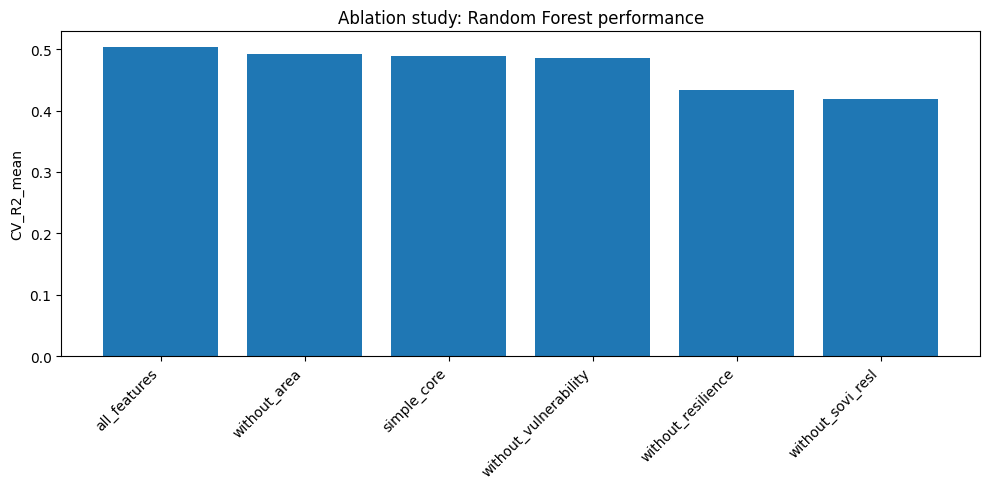

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(ablation_df["feature_set"], ablation_df["CV_R2_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean cross-validated R²")
plt.xlabel("Feature set")
plt.tight_layout()
save_current_figure("figure_1_ablation_cv_r2")
plt.show()


# **Cell 8 — Choose best feature set**

In [ ]:
best_feature_set = ablation_df.iloc[0]["feature_set"]
print("Best feature set:", best_feature_set)

best_result = ablation_results[best_feature_set]
best_features = feature_sets[best_feature_set]

print("Best features:")
print(best_features)


Best feature set: all_features
Best features:
['population', 'building_value', 'agriculture_value', 'area_sq_mi', 'social_vulnerability_score', 'community_resilience_score', 'population_density', 'building_value_density', 'agriculture_value_density', 'building_value_per_capita']


# **Cell 9 — Feature importance for best feature set**

,feature,importance
3,area_sq_mi,0.392515
5,community_resilience_score,0.110084
0,population,0.083992
9,building_value_per_capita,0.072952
8,agriculture_value_density,0.069897
4,social_vulnerability_score,0.068564
2,agriculture_value,0.059402
1,building_value,0.054632
6,population_density,0.044628
7,building_value_density,0.043336


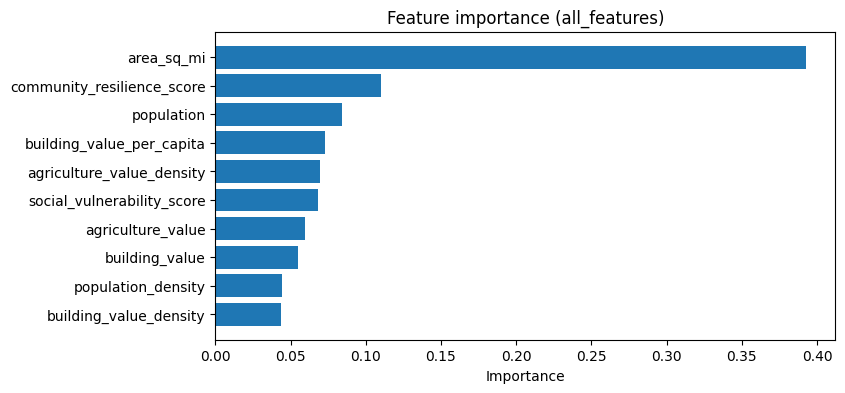

In [ ]:
best_pipe = best_result["pipe"]
rf_model = best_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": best_features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

# Thesis export: feature importance table
importance_export = importance_df.rename(columns={
    "feature": "Feature",
    "importance": "Random Forest importance"
})
importance_export.to_csv(EXPORT_DIR / "table_2_best_feature_importance.csv", index=False)
save_dataframe_table(
    importance_export,
    "table_2_best_feature_importance.pdf",
    f"Table 2. Feature Importance for Best Ablation ({best_feature_set})",
    fontsize=8,
    fig_width=10
)

plt.figure(figsize=(8, 4.8))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Random Forest feature importance")
plt.tight_layout()
save_current_figure("figure_2_best_feature_importance")
plt.show()


# **Cell 10 — Build error analysis table**

In [ ]:
X_test_best = best_result["X_test"].copy()
y_test_best = best_result["y_test"]
y_pred_best = best_result["y_pred"]

error_df = X_test_best.copy()
error_df["actual_log_wildfire_eal"] = y_test_best.values
error_df["predicted_log_wildfire_eal"] = y_pred_best
error_df["residual"] = error_df["actual_log_wildfire_eal"] - error_df["predicted_log_wildfire_eal"]
error_df["abs_error"] = np.abs(error_df["residual"])

# Attach identifiers
error_df = error_df.merge(
    df[["county_fips", "state", "county", "wildfire_eal"]],
    left_index=True,
    right_index=True,
    how="left"
)

display(error_df.head())

# Thesis export: compact error summary for the best model
error_summary_df = pd.DataFrame({
    "Item": [
        "Best feature set",
        "Test records",
        "MAE on log target",
        "RMSE on log target",
        "Test R2",
        "CV R2 mean",
        "CV RMSE mean",
        "Median absolute error",
        "Maximum absolute error"
    ],
    "Value": [
        best_feature_set,
        len(error_df),
        best_result["MAE"],
        best_result["RMSE"],
        best_result["R2"],
        best_result["CV_R2_mean"],
        best_result["CV_RMSE_mean"],
        error_df["abs_error"].median(),
        error_df["abs_error"].max()
    ]
})

display(error_summary_df)

error_summary_df.to_csv(EXPORT_DIR / "table_3_best_model_error_summary.csv", index=False)
save_dataframe_table(
    error_summary_df,
    "table_3_best_model_error_summary.pdf",
    "Table 3. Best Ablation Model Error Summary",
    fontsize=8,
    fig_width=9
)


,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita,actual_log_wildfire_eal,predicted_log_wildfire_eal,residual,abs_error,county_fips,state,county,wildfire_eal
2993,7802,2.217567e+09,2610595.0,323.711289,33.269720,49.332061,24.101724,6.850447e+06,8064.578178,2.842306e+05,8.164677,8.578312,-0.413635,0.413635,54017,West Virginia,Doddridge,3513.585164
2971,13347,3.360830e+09,6091081.0,1439.889378,40.108142,21.882952,9.269462,2.334089e+06,4230.242331,2.518041e+05,12.614285,12.804295,-0.190011,0.190011,53051,Washington,Pend Oreille,300824.178107
1064,31629,7.710983e+09,66164981.0,343.604688,40.553435,64.249364,92.050549,2.244144e+07,192561.345497,2.437947e+05,9.454494,9.163742,0.290753,0.290753,21157,Kentucky,Marshall,12764.405796
1987,6379,7.321097e+09,277399333.0,1714.834748,31.106870,58.746819,3.719892,4.269273e+06,161764.469344,1.147687e+06,13.505041,13.005501,0.499540,0.499540,38009,North Dakota,Bottineau,733101.683265
2990,94158,2.250201e+10,3458170.0,290.924398,59.160305,73.854962,323.651095,7.734659e+07,11886.833910,2.389814e+05,11.879688,10.511084,1.368605,1.368605,54011,West Virginia,Cabell,144304.576582


# **Cell 11 — Biggest underpredictions**

These are counties where actual risk was much higher than predicted.

In [ ]:
underpred_df = error_df.sort_values("residual", ascending=False).head(20)

underpred_export = underpred_df[
    ["state", "county", "county_fips", "wildfire_eal",
     "actual_log_wildfire_eal", "predicted_log_wildfire_eal",
     "residual", "abs_error"]
].rename(columns={
    "state": "State",
    "county": "County",
    "county_fips": "FIPS",
    "wildfire_eal": "Wildfire EAL",
    "actual_log_wildfire_eal": "Actual log EAL",
    "predicted_log_wildfire_eal": "Predicted log EAL",
    "residual": "Residual",
    "abs_error": "Abs. error"
})

display(underpred_export)

underpred_export.to_csv(EXPORT_DIR / "table_4_top20_underpredicted_counties.csv", index=False)
save_dataframe_table(
    underpred_export,
    "table_4_top20_underpredicted_counties.pdf",
    "Table 4. Top 20 Underpredicted Counties",
    fontsize=6.5,
    fig_width=16
)


,state,county,county_fips,wildfire_eal,actual_log_wildfire_eal,predicted_log_wildfire_eal,residual,abs_error
93,Alaska,Southeast Fairbanks,02240,4.886402e+06,15.401967,9.881640,5.520327,5.520327
1803,New Mexico,Los Alamos,35028,1.179326e+06,13.980454,8.615654,5.364801,5.364801
1735,Nebraska,Washington,31177,8.392379e+05,13.640251,8.324555,5.315695,5.315695
218,California,Plumas,06063,1.318049e+07,16.394249,11.091864,5.302385,5.302385
214,California,Napa,06055,4.850532e+06,15.394599,10.636164,4.758435,4.758435
544,Idaho,Ada,16001,2.659064e+07,17.096070,12.659464,4.436606,4.436606
2728,Texas,Somervell,48425,6.770761e+05,13.425540,9.083905,4.341635,4.341635
251,Colorado,Boulder,08013,1.570084e+07,16.569225,12.364952,4.204274,4.204274
581,Idaho,Payette,16075,1.715086e+06,14.354975,10.150754,4.204221,4.204221
203,California,Lake,06033,2.033949e+07,16.828075,12.695874,4.132201,4.132201


# **Cell 12 — Biggest overpredictions**

These are counties where predicted risk was much higher than actual.

In [ ]:
overpred_df = error_df.sort_values("residual", ascending=True).head(20)

overpred_export = overpred_df[
    ["state", "county", "county_fips", "wildfire_eal",
     "actual_log_wildfire_eal", "predicted_log_wildfire_eal",
     "residual", "abs_error"]
].rename(columns={
    "state": "State",
    "county": "County",
    "county_fips": "FIPS",
    "wildfire_eal": "Wildfire EAL",
    "actual_log_wildfire_eal": "Actual log EAL",
    "predicted_log_wildfire_eal": "Predicted log EAL",
    "residual": "Residual",
    "abs_error": "Abs. error"
})

display(overpred_export)

overpred_export.to_csv(EXPORT_DIR / "table_5_top20_overpredicted_counties.csv", index=False)
save_dataframe_table(
    overpred_export,
    "table_5_top20_overpredicted_counties.pdf",
    "Table 5. Top 20 Overpredicted Counties",
    fontsize=6.5,
    fig_width=16
)


,state,county,county_fips,wildfire_eal,actual_log_wildfire_eal,predicted_log_wildfire_eal,residual,abs_error
67,Alaska,Aleutians East,02013,6.317189,1.990226,8.647676,-6.657450,6.657450
3035,West Virginia,Webster,54101,460.731895,6.134984,11.690752,-5.555768,5.555768
1179,Maine,Penobscot,23019,14351.565536,9.571684,14.525123,-4.953439,4.953439
1174,Maine,Hancock,23009,3741.749451,8.227576,12.935588,-4.708013,4.708013
2755,Texas,Webb,48479,65969.467878,11.096962,15.801716,-4.704754,4.704754
1760,New Hampshire,Coos,33007,4935.825576,8.504478,13.107558,-4.603081,4.603081
111,Arizona,Yuma,04027,58461.928520,10.976148,15.245578,-4.269430,4.269430
2117,Ohio,Vinton,39163,979.651664,6.888217,10.289320,-3.401102,3.401102
1159,Louisiana,Tensas,22107,1238.237410,7.122251,10.393833,-3.271582,3.271582
680,Illinois,Wabash,17185,173.028321,5.159218,8.415416,-3.256198,3.256198


# **Cell 13 — Absolute error distribution**

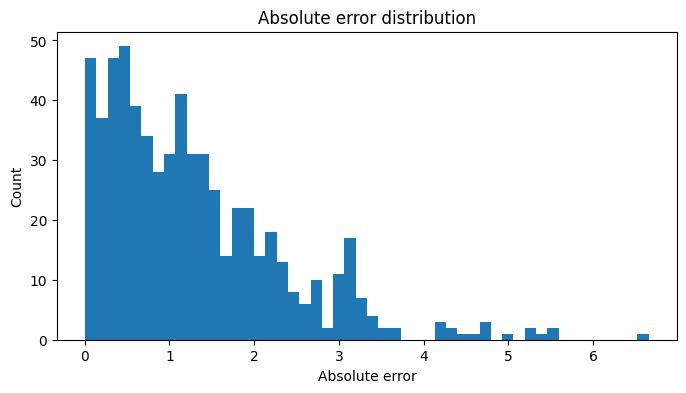

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(error_df["abs_error"], bins=50)
plt.xlabel("Absolute error on log wildfire EAL")
plt.ylabel("County count")
plt.tight_layout()
save_current_figure("figure_3_absolute_error_distribution")
plt.show()


# **Cell 14 — Predicted vs actual for best ablation**

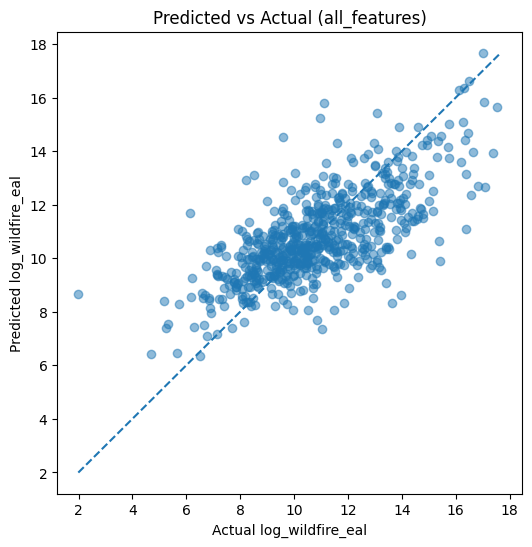

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(error_df["actual_log_wildfire_eal"], error_df["predicted_log_wildfire_eal"], alpha=0.5)
plt.xlabel("Actual log wildfire EAL")
plt.ylabel("Predicted log wildfire EAL")

min_val = min(error_df["actual_log_wildfire_eal"].min(), error_df["predicted_log_wildfire_eal"].min())
max_val = max(error_df["actual_log_wildfire_eal"].max(), error_df["predicted_log_wildfire_eal"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.tight_layout()
save_current_figure("figure_4_predicted_vs_actual")
plt.show()


# **Cell 15 — Save outputs**

In [ ]:
ABLATION_OUT = EXPORT_DIR / "wildfire_risk_ablation_results.csv"
IMPORTANCE_OUT = EXPORT_DIR / "wildfire_risk_best_feature_importance.csv"
ERROR_OUT = EXPORT_DIR / "wildfire_risk_error_analysis.csv"

ablation_df.to_csv(ABLATION_OUT, index=False)
importance_df.to_csv(IMPORTANCE_OUT, index=False)
error_df.to_csv(ERROR_OUT, index=False)

print("Saved:", ABLATION_OUT)
print("Saved:", IMPORTANCE_OUT)
print("Saved:", ERROR_OUT)

print("\nNotebook 4 thesis exports completed.")
print("Export folder:", EXPORT_DIR.resolve())


Saved: /content/wildfire_risk_ablation_results.csv
Saved: /content/wildfire_risk_best_feature_importance.csv
Saved: /content/wildfire_risk_error_analysis.csv
